In [ ]:
import kagglehub

path = kagglehub.dataset_download("zibranzarif/pasta-shape-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.09G/2.09G [02:01<00:00, 18.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1


In [ ]:
import os
dataset_path = '/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1'

#viewing number of images in the folder
#doesn't work directly due to nested folders

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

cannelloni: 1 images
tortellini: 1 images
gemelli: 1 images
spaghetti: 1 images
conchiglie: 1 images
lasagna: 1 images
tagliatelle: 1 images
penne: 1 images
cavatappi: 1 images
ravioli: 1 images
fusilli: 1 images
bucatini: 1 images
rigatoni: 1 images
linguine: 1 images
orecchiette: 1 images
fettuccine: 1 images
macaroni: 1 images
orzo: 1 images
rotini: 1 images
farfalle: 1 images


In [ ]:
#succesfully views the images in each nested folder
for root, dirs, files in os.walk(dataset_path):
    if files:
        print(f"{root}: {len(files)} images")

/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/cannelloni/cannelloni: 371 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/tortellini/tortellini: 414 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/gemelli/gemelli: 357 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/spaghetti/spaghetti: 360 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/conchiglie/conchiglie: 367 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/lasagna/lasagna: 355 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/tagliatelle/tagliatelle: 319 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/penne/penne: 368 images
/root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/cavatappi/cavatappi: 376 images
/root/.cache/kagglehub/datasets/zibranzarif

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

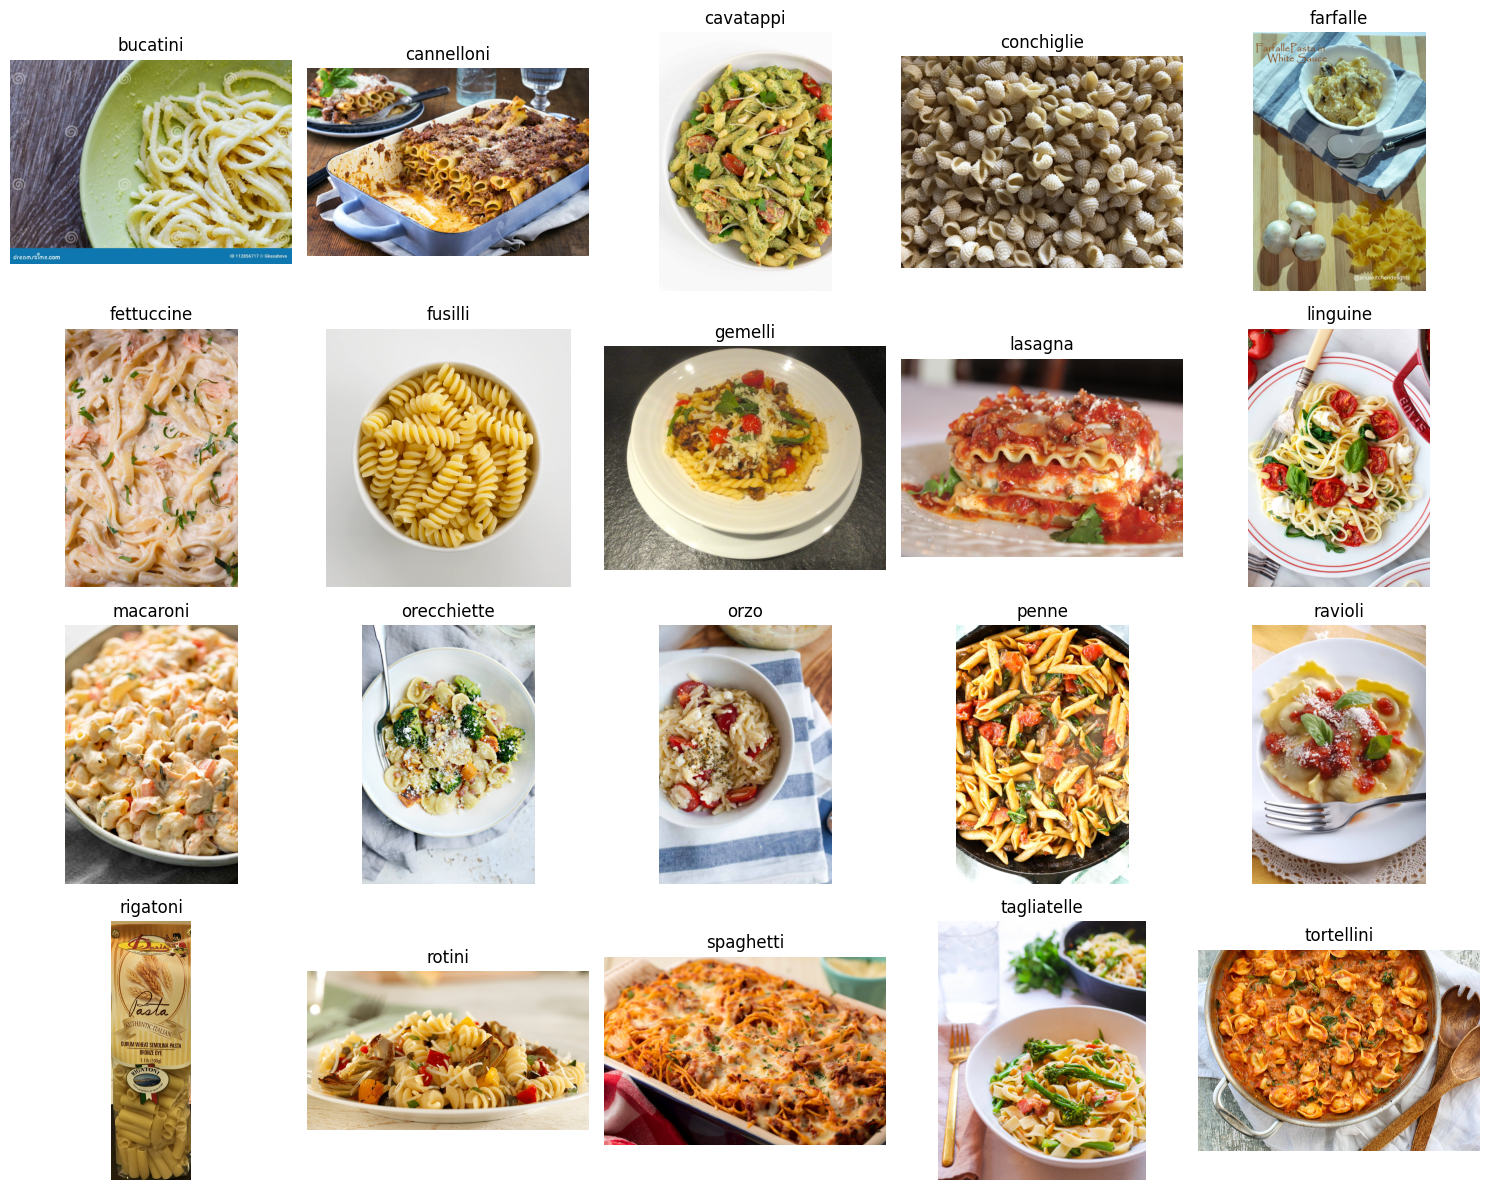

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

#loops thourgh every pasta type folder and display a picture randomly for each pasta type
for idx, folder in enumerate(sorted(os.listdir(dataset_path))):
    inner_path = os.path.join(dataset_path, folder, folder)      #creates a path to each image to help with the nesting issue
    if os.path.isdir(inner_path):
        images = os.listdir(inner_path)                          #puts every image in a 'images list'
        random_img = random.choice(images)                       #grabs an image randomly from the list
        img = mpimg.imread(os.path.join(inner_path, random_img)) #grabs an image
        axes[idx].imshow(img)                                    #displays it
        axes[idx].set_title(folder)                              #sets folder name(aka pasta type) as the title
        axes[idx].axis('off')                                    #turns axis titles off

plt.tight_layout()            #formattes the images neatly
plt.show()                    #shows the final result

In [ ]:
#imporint pytorch and some related libraries for our task
import torch
from torchvision import datasets, transforms  #for image tasks
from torch.utils.data import DataLoader, random_split  #to manage data

In [ ]:
#transforms images as neeeded
transform = transforms.Compose([
    transforms.Resize((224, 224)),  #resized images to the same size
    transforms.ToTensor(),          #turns a image into a pytorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])   #normalizing (idk what that means)
])
dataset = datasets.ImageFolder(root=dataset_path, transform=transform) #this loader reads folder and truns folder name into class label
print('total images:', len(dataset))
print('Classes:', dataset.classes)

total images: 7288
Classes: ['bucatini', 'cannelloni', 'cavatappi', 'conchiglie', 'farfalle', 'fettuccine', 'fusilli', 'gemelli', 'lasagna', 'linguine', 'macaroni', 'orecchiette', 'orzo', 'penne', 'ravioli', 'rigatoni', 'rotini', 'spaghetti', 'tagliatelle', 'tortellini']


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

#faced an issue wth corrupted data i didn't account for prevously. so i added a class that goes through the images and removes corrupted images
class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        self.classes = sorted(os.listdir(root))                        #sorts the classes
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)} #assigns an index

        #kooos through each pasta class
        for label in self.classes:
            inner = os.path.join(root, label, label)
            if not os.path.isdir(inner): #skips if inner folder does not exist
                continue
            for fname in os.listdir(inner):
                path = os.path.join(inner, fname)
                try:
                    img = Image.open(path)                                #tries to open every eage file
                    img.verify()                                          #and verify it
                    self.samples.append((path, self.class_to_idx[label])) #append to the samples folder
                except:
                    print(f"Skipping bad image: {path}")                  #if fails to do that, skip the bad image

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

dataset = SafeImageFolder(root=dataset_path, transform=transform)
print(f"Clean dataset size: {len(dataset)}")

Skipping bad image: /root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/linguine/linguine/170ddc97-0b62-4ab3-98ae-dfb3e7a5c110.asp
Skipping bad image: /root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/linguine/linguine/422f388d-8daa-4066-8399-f0caf6c85601.webp
Clean dataset size: 7302


In [ ]:
#basically doing train-test-split hehe
train_size = int(0.8 * len(dataset))      #80% data used for training
test_size = len(dataset) - train_size     #20% data used for testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size]) #spliting the dataset

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) '''loads train data in batches.
                                                                         32 images at a time.
                                                                         shuffles the dataset for training so model doesn't train based on the order of the images'''

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)  #testing does not require shuffling

In [ ]:
print(f"Training images: {train_size}")
print(f"Validation images: {test_size}")

Training images: 5841
Validation images: 1461


In [ ]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights #from pytorche's vision models, we imported resnet 18

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  #loads ResNet18's pretrained weights as our model as our model
num_ftrs = model.fc.in_features                           #stores how many inputs ResNet's final layer expects (512)
model.fc = nn.Linear(num_ftrs, len(dataset.classes))      #ResNet18 gives output of 1000 ImageNet classes we modify it to the number of pasta shape classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #checks if colab gpu is available
model = model.to(device)

print('using device:', device)

using device: cuda


In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()                    #Loss function. Determines how wrong the model is
optimizer = optim.Adam(model.parameters(), lr=0.001) #decides how the model updates its knowledge

# RUN 01


In [ ]:
from tqdm import tqdm
epochs = 10     #the whole dataset is 'seen' by the model for 10 times

for epoch in range(epochs):
  model.train()     #training mode on
  train_loss = 0
  correct = 0
  total = 0

  loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}") #progressbar for me :)
  #working on training data first
  for images, labels in loop:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()       #clears old gradients
    outputs = model(images)     #makes predictions
    loss = criterion(outputs, labels)
    #backpropagation
    loss.backward()     #calculates how much wight contributed in the error
    optimizer.step()    #updates model weight
    train_loss += loss.item()
    _, predicted = outputs.max(1)
    correct += predicted.eq(labels).sum().item()
    total += labels.size(0)
    loop.set_postfix(loss=loss.item(), acc=100.*correct/total) #updates progressbar in real-time

  model.eval()    #evaluation mode on
  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
      _, predicted = outputs.max(1)
      val_correct += predicted.eq(labels).sum().item()
      val_total += labels.size(0)

  print(f"Epoch {epoch+1}/{epochs}")
  print(f"Train Loss: {train_loss/len(train_loader)}")
  print(f"Train Accuracy: {correct/total}")
  print(f"Validation Loss: {val_loss/len(test_loader)}")
  print(f"Validation Accuracy: {val_correct/val_total}")


Epoch 1/10:   4%|▍         | 7/183 [00:08<03:24,  1.16s/it, acc=85.7, loss=0.568]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/10:  90%|████████▉ | 164/183 [03:37<00:27,  1.45s/it, acc=84.7, loss=0.671]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))
Epoch 1/10: 100%|██████████| 183/183 [04:02<00:00,  1.32s/it, acc=84.2, loss=0.286]


Epoch 1/10
Train Loss: 0.4673828658510427
Train Accuracy: 0.8419791131655538
Validation Loss: 1.9563178549642148
Validation Accuracy: 0.5044490075290896


Epoch 2/10: 100%|██████████| 183/183 [04:07<00:00,  1.35s/it, acc=90.2, loss=0.765]


Epoch 2/10
Train Loss: 0.3077579834014992
Train Accuracy: 0.9020715630885122
Validation Loss: 1.1364786812792653
Validation Accuracy: 0.7091033538672142


Epoch 3/10: 100%|██████████| 183/183 [04:03<00:00,  1.33s/it, acc=91.8, loss=1.45]


...

Epoch 8/10
Train Loss: 0.2127623429593167
Train Accuracy: 0.9308337613422359
Validation Loss: 2.950379467528799
Validation Accuracy: 0.5455167693360712


Epoch 9/10: 100%|██████████| 183/183 [04:04<00:00,  1.33s/it, acc=93.6, loss=0.252]


Epoch 9/10
Train Loss: 0.19529178910608827
Train Accuracy: 0.9364834788563602
Validation Loss: 1.440852908336598
Validation Accuracy: 0.7070499657768652


Epoch 10/10: 100%|██████████| 183/183 [04:04<00:00,  1.34s/it, acc=96.4, loss=0.0917]


Epoch 10/10
Train Loss: 0.10850791999805576
Train Accuracy: 0.9640472521828454
Validation Loss: 1.6325770642446435
Validation Accuracy: 0.6673511293634496


#RUN 02

In [ ]:
#augmentation for training set
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),                                     #flips horizontally
    transforms.RandomRotation(15),                                         #rotates randomly upto 15 degrees
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  #randomly changes brightness, contrast and saturation
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),              #shifts the image
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#for validation set only resized, turned into a tensor, and normalized
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import Subset

#full dataset with no transform
full_dataset = SafeImageFolder(root= dataset_path, transform=None)

#splitting the data
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_indices, val_indices = torch.utils.data.random_split(range(len(full_dataset)), [train_size, val_size])

# Applying different transforms to each split
class TransformDataset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = TransformDataset(full_dataset, train_indices, train_transform)
val_dataset = TransformDataset(full_dataset, val_indices, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

Skipping bad image: /root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/linguine/linguine/170ddc97-0b62-4ab3-98ae-dfb3e7a5c110.asp
Skipping bad image: /root/.cache/kagglehub/datasets/zibranzarif/pasta-shape-dataset/versions/1/linguine/linguine/422f388d-8daa-4066-8399-f0caf6c85601.webp
Train size: 5841
Val size: 1461


In [ ]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler - reduces lr (learning rate) by half if val accuracy doesn't improve for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print("Model reset and ready!")

Model reset and ready!


In [ ]:
best_val_acc = 0
best_epoch = 0

epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    train_acc = 100.*correct/total
    val_acc = 100.*val_correct/val_total

    scheduler.step(val_acc)    #tells the scheduler the current val accuracy

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth') #saves model weights for the best epoch

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Best: {best_val_acc:.1f}% (epoch {best_epoch})")

Epoch 1/10: 100%|██████████| 183/183 [04:19<00:00,  1.42s/it, acc=28.3, loss=1.65]


Epoch 1/10 | Train Acc: 28.3% | Val Acc: 24.0% | Best: 24.0% (epoch 1)


Epoch 2/10: 100%|██████████| 183/183 [04:19<00:00,  1.42s/it, acc=43.8, loss=1.93]


Epoch 2/10 | Train Acc: 43.8% | Val Acc: 28.4% | Best: 28.4% (epoch 2)


Epoch 3/10: 100%|██████████| 183/183 [04:18<00:00,  1.41s/it, acc=49.5, loss=1.38]


...

Epoch 8/10 | Train Acc: 68.3% | Val Acc: 54.6% | Best: 54.6% (epoch 8)


Epoch 9/10: 100%|██████████| 183/183 [04:15<00:00,  1.40s/it, acc=68.4, loss=0.944]


Epoch 9/10 | Train Acc: 68.4% | Val Acc: 50.8% | Best: 54.6% (epoch 8)


Epoch 10/10: 100%|██████████| 183/183 [04:21<00:00,  1.43s/it, acc=72.4, loss=0.694]


Epoch 10/10 | Train Acc: 72.4% | Val Acc: 57.2% | Best: 57.2% (epoch 10)


#RUN 03

In [ ]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(full_dataset.classes))

#freezes all layers of ResNet18 except layer4(detects high level features, obejct specific) and fc (final decision layer)
#other layers are universal, no need to relearn that
for name, param in model.named_parameters():
    if not any(x in name for x in ['layer4', 'fc']):
        param.requires_grad = False

model = model.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001) #only passes unfrozen parameters
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) #checks how many parameters are trainable
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")

Trainable parameters: 8,403,988 / 11,186,772


In [ ]:
#revised augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = TransformDataset(full_dataset, train_indices, train_transform)
val_dataset = TransformDataset(full_dataset, val_indices, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Dataloaders ready!")

Dataloaders ready!


In [ ]:
best_val_acc = 0
best_epoch = 0

epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    train_acc = 100.*correct/total
    val_acc = 100.*val_correct/val_total

    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | Best: {best_val_acc:.1f}% (epoch {best_epoch})")

Epoch 1/20: 100%|██████████| 183/183 [04:08<00:00,  1.36s/it, acc=45.8, loss=1.21]


Epoch 1/20 | Train Acc: 45.8% | Val Acc: 51.2% | Best: 51.2% (epoch 1)


Epoch 2/20: 100%|██████████| 183/183 [04:04<00:00,  1.34s/it, acc=62.1, loss=1.12]


Epoch 2/20 | Train Acc: 62.1% | Val Acc: 61.5% | Best: 61.5% (epoch 2)


Epoch 3/20: 100%|██████████| 183/183 [04:05<00:00,  1.34s/it, acc=69.4, loss=0.567]


...

Epoch 18/20 | Train Acc: 98.4% | Val Acc: 77.3% | Best: 77.7% (epoch 16)


Epoch 19/20: 100%|██████████| 183/183 [04:03<00:00,  1.33s/it, acc=98.4, loss=0.0779]


Epoch 19/20 | Train Acc: 98.4% | Val Acc: 78.5% | Best: 78.5% (epoch 19)


Epoch 20/20: 100%|██████████| 183/183 [04:02<00:00,  1.32s/it, acc=98.5, loss=0.0211]


Epoch 20/20 | Train Acc: 98.5% | Val Acc: 78.0% | Best: 78.5% (epoch 19)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


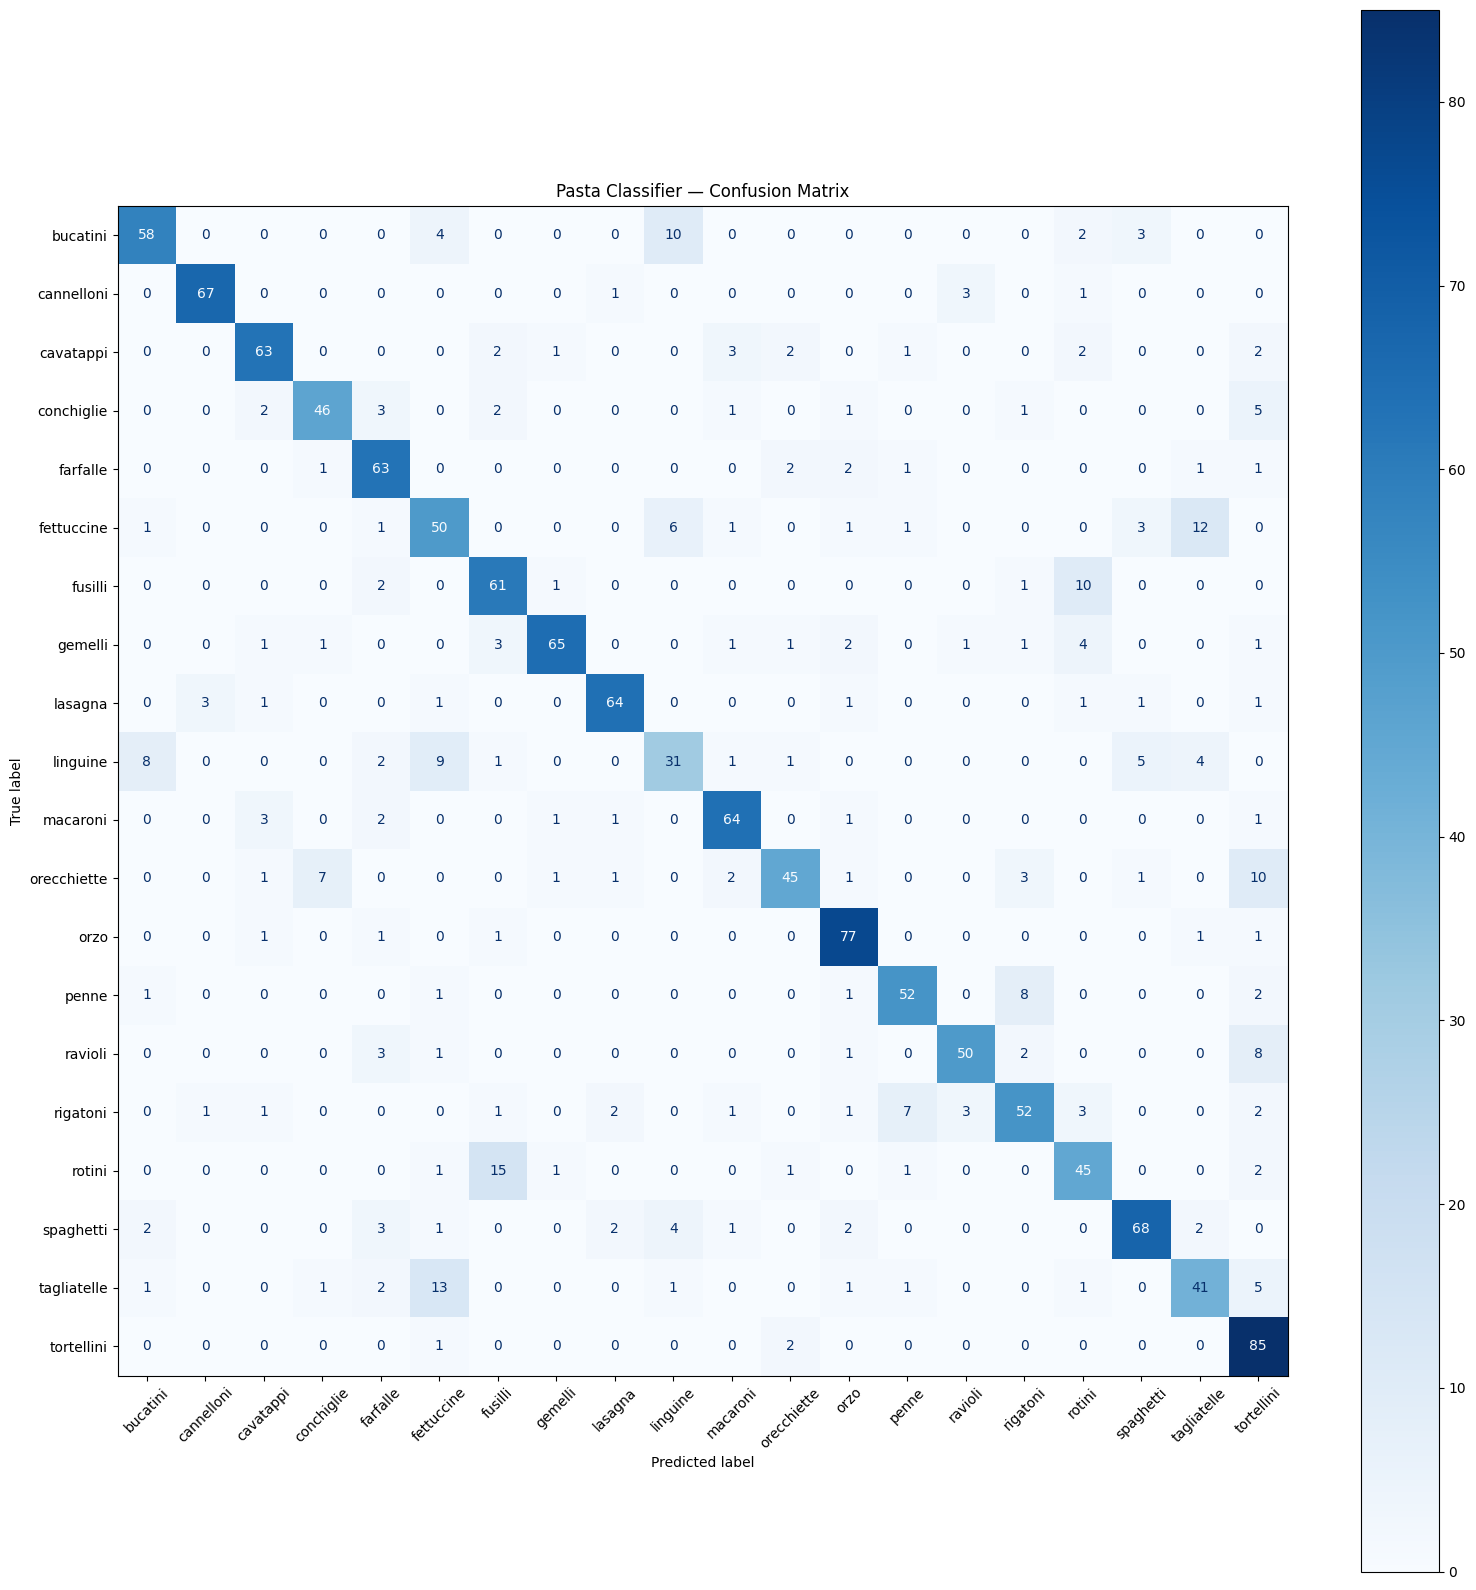

In [ ]:
#implementing confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get all predictions on validation set
model.eval()
all_preds = []
all_labels = []


with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

#plotting the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title("Pasta Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()


Saving Screenshot 2026-05-27 210947.png to Screenshot 2026-05-27 210947.png

🍝 Pasta Classifier Results:
------------------------------
#1 tagliatelle: 99.7%
#2 gemelli: 0.2%
#3 penne: 0.1%


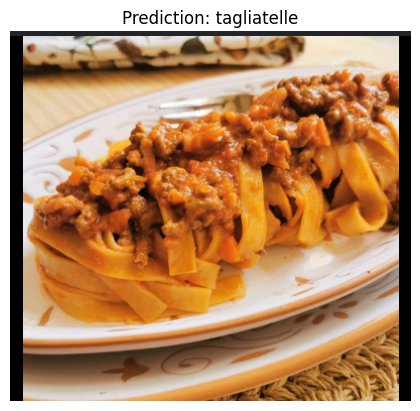

In [ ]:
from google.colab import files
from PIL import Image
import torch.nn.functional as F

#Load best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Upload an image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

#Open the image file and turn into a tensor
img = Image.open(img_path).convert("RGB")
img_tensor = val_transform(img).unsqueeze(0).to(device)

#Predict
with torch.no_grad():
    outputs = model(img_tensor)
    probs = F.softmax(outputs, dim=1)
    top3_probs, top3_indices = torch.topk(probs, 3)

#Show results
print("\n🍝 Pasta Classifier Results:")
print("-" * 30)
for i in range(3):
    class_name = full_dataset.classes[top3_indices[0][i]]
    probability = top3_probs[0][i].item() * 100
    print(f"#{i+1} {class_name}: {probability:.1f}%")

#Show the image
plt.imshow(Image.open(img_path))
plt.title(f"Prediction: {full_dataset.classes[top3_indices[0][0]]}")
plt.axis('off')
plt.show()